# M6 CASE STUDY

## Background

An insurance policy is an arrangement by which a company undertakes to provide a guarantee of compensation for specified loss, damage, illness, or death in return for the payment of a specified premium. A premium is a sum of money that the customer needs to pay regularly to an insurance company for this guarantee. Just like medical insurance, there is vehicle insurance where every year customer needs to pay a premium of certain amount to insurance provider company so that in case of unfortunate accident by the vehicle, the insurance provider company will provide a compensation (called ‘sum assured’) to the customer. 

The marketing campaign was launched for existing health insurance customers to cross sell vehicle insurance. The data for the study includes campaign response details along with customer demographics 
and policy details.

### Objectives

Develop a Campaign Response Prediction Model using the XGBoost algorithm.

Implement multiple XGBoost models with different hyperparameters and select the best-performing model based on ROC-AUC.


### Data Description

| Variable                 | Description                                                                                                      |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------- |
| **id**                   | Unique customer identifier.                                                                                      |
| **Previously_Insured**   | Indicates whether the customer already has vehicle insurance (1 = Yes, 0 = No).                                  |
| **Vehicle_Age**          | Age category of the vehicle (`< 1 Year`, `1-2 Year`, `> 2 Years`).                                               |
| **Vehicle_Damage**       | Indicates whether the vehicle was previously damaged (Yes/No).                                                   |
| **Annual_Premium**       | Amount paid annually by the customer for health insurance coverage.                                              |
| **Policy_Sales_Channel** | Encoded channel through which the customer was contacted (e.g., agent, online, telemarketing).                   |
| **Vintage**              | Number of days the customer has been associated with the company.                                                |
| **Gender**               | Gender of the customer (Male/Female).                                                                            |
| **Age**                  | Age of the customer.                                                                                             |
| **Driving_License**      | Indicates whether the customer holds a valid driving license (1 = Yes, 0 = No).                                  |
| **Region_Code**          | Code representing the geographical region of the customer.                                                       |
| **Response**             | Target variable indicating whether the customer is interested in purchasing vehicle insurance (1 = Yes, 0 = No). |


### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt

### 2. Load Datasets

In [2]:
df1 = pd.read_csv('Policy Details.csv')
df1.head()

,id,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,1,0,> 2 Years,Yes,40454,26,217
1,2,0,1-2 Year,No,33536,26,183
2,3,0,> 2 Years,Yes,38294,26,27
3,4,1,< 1 Year,No,28619,152,203
4,5,1,< 1 Year,No,27496,152,39


In [3]:
df2 = pd.read_csv('Customer Demographics.csv')
df2.head()

,id,Gender,Age,Driving_License,Region_Code
0,1,Male,44,1,28
1,2,Male,76,1,3
2,3,Male,47,1,28
3,4,Male,21,1,11
4,5,Female,29,1,41


In [4]:
df3 = pd.read_csv('Campaign Response.csv')
df3.head()

,id,Response
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0


In [5]:
master = pd.merge(df1,df2,on = ['id'])
master = master.merge(df3,on = ['id'])
master.head()

,id,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Gender,Age,Driving_License,Region_Code,Response
0,1,0,> 2 Years,Yes,40454,26,217,Male,44,1,28,1
1,2,0,1-2 Year,No,33536,26,183,Male,76,1,3,0
2,3,0,> 2 Years,Yes,38294,26,27,Male,47,1,28,1
3,4,1,< 1 Year,No,28619,152,203,Male,21,1,11,0
4,5,1,< 1 Year,No,27496,152,39,Female,29,1,41,0


In [6]:
# Drop ID column
master = master.drop(columns=['id'])
print(master.shape)

(381109, 11)


### 3. Define Features


In [7]:
X = master.drop("Response", axis=1)
y = master["Response"]

cat_cols = ['Gender','Vehicle_Age','Vehicle_Damage']
num_cols = [col for col in X.columns if col not in cat_cols]

### 4. Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(285831, 10) (95278, 10)


### 5. Feature Engineering

In [9]:
#Policy_Sales_Channel
freq_psc = X_train['Policy_Sales_Channel'].value_counts(normalize=True)

X_train['PSC_freq'] = X_train['Policy_Sales_Channel'].map(freq_psc)
X_test['PSC_freq']  = X_test['Policy_Sales_Channel'].map(freq_psc)

X_test['PSC_freq'] = X_test['PSC_freq'].fillna(0)


#Region_Code
freq_region = X_train['Region_Code'].value_counts(normalize=True)

X_train['Region_freq'] = X_train['Region_Code'].map(freq_region)
X_test['Region_freq']  = X_test['Region_Code'].map(freq_region)

X_test['Region_freq'] = X_test['Region_freq'].fillna(0)


#Drop original high-cardinality columns
X_train = X_train.drop(columns=['Policy_Sales_Channel','Region_Code'])
X_test  = X_test.drop(columns=['Policy_Sales_Channel','Region_Code'])

### 6. Handle Class Imbalance

In [10]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 7.159140214660882


### 7. Preprocessing Pipeline

In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

### 8. Build XGBoost Model

In [12]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb_model)
])

### 9. Train Model

In [13]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 10. Predictions

In [14]:
y_pred_prob = pipeline.predict_proba(X_test)[:,1]
y_pred = pipeline.predict(X_test)

auc = roc_auc_score(y_test, y_pred_prob)

print("AUC Score:", auc)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

AUC Score: 0.8549530406620717

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.70      0.82     83600
           1       0.29      0.89      0.44     11678

    accuracy                           0.72     95278
   macro avg       0.64      0.80      0.63     95278
weighted avg       0.90      0.72      0.77     95278



### 11. Hyperparameter Tuning

In [15]:
param_dist = {

    'model__max_depth':[4,5,6,7],
    'model__learning_rate':[0.01,0.03,0.05,0.1],
    'model__subsample':[0.6,0.8,1],
    'model__colsample_bytree':[0.6,0.8,1],
    'model__min_child_weight':[1,3,5],
    'model__gamma':[0,0.1,0.3]

}

random_search = RandomizedSearchCV(

    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42

)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'model__subsample': 0.8, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}


### 12. Final Model Evaluation

In [16]:
y_pred_prob = best_model.predict_proba(X_test)[:,1]
y_pred = best_model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_prob)

print("\nOptimized Model AUC:", auc)

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Optimized Model AUC: 0.8578835131245026

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     83600
           1       0.28      0.93      0.43     11678

    accuracy                           0.70     95278
   macro avg       0.63      0.80      0.62     95278
weighted avg       0.90      0.70      0.76     95278



### 13. SHAP Explainability

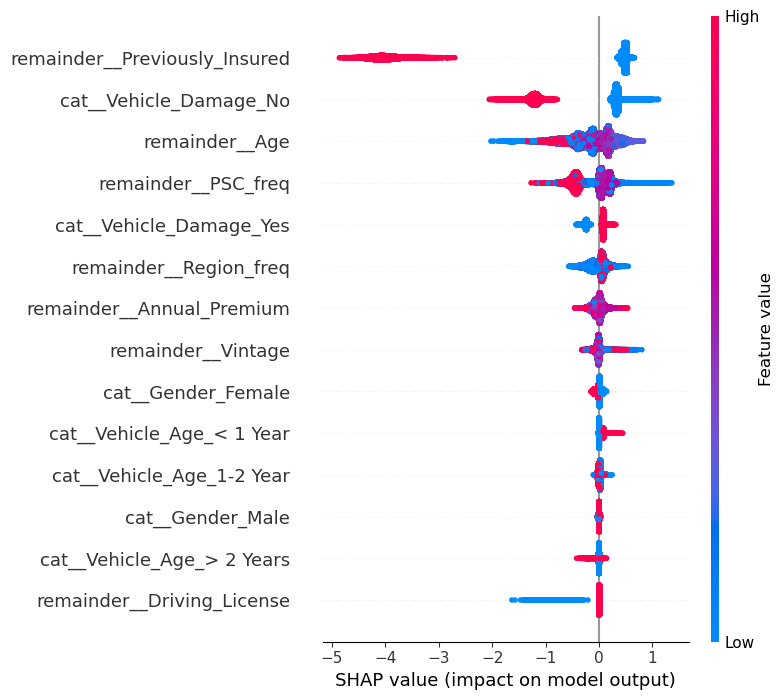

In [17]:
# Transform data for SHAP
X_train_transformed = best_model.named_steps['preprocess'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocess'].transform(X_test)

feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

explainer = shap.TreeExplainer(best_model.named_steps['model'])

shap_values = explainer(X_test_transformed)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

### SHAP Bar Importance

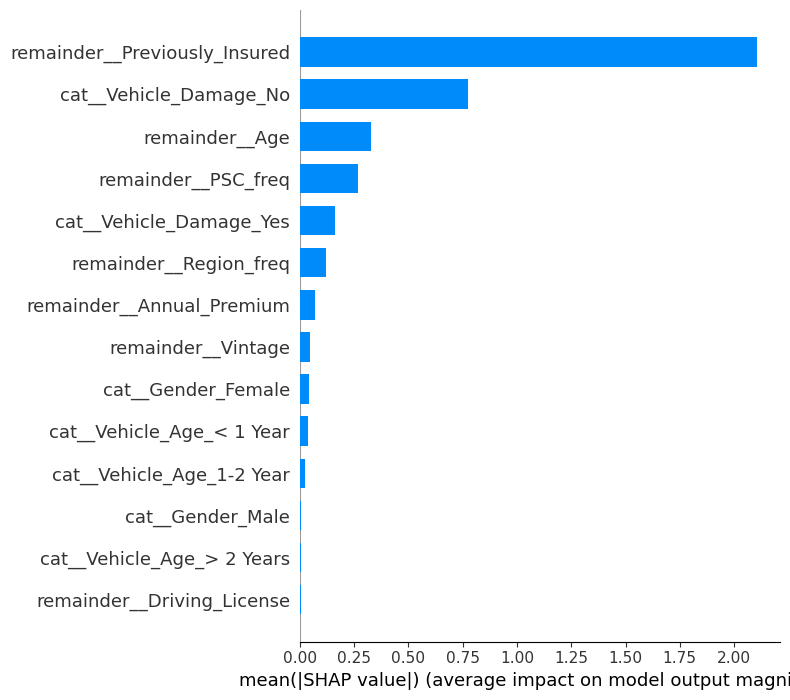

In [18]:
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names,
                  plot_type="bar")

### Business Interpretation

In [19]:
print("\nTop Important Features")

importances = best_model.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
})

imp_df = imp_df.sort_values(by="Importance", ascending=False)

print(imp_df.head(10))


Top Important Features
                          Feature  Importance
7   remainder__Previously_Insured    0.500732
6         cat__Vehicle_Damage_Yes    0.248132
5          cat__Vehicle_Damage_No    0.220392
10                 remainder__Age    0.006661
12            remainder__PSC_freq    0.004187
3       cat__Vehicle_Age_< 1 Year    0.003836
2       cat__Vehicle_Age_1-2 Year    0.003091
11     remainder__Driving_License    0.002792
4      cat__Vehicle_Age_> 2 Years    0.002474
13         remainder__Region_freq    0.002027
